In [6]:
import re
import pandas as pd
import json

In [80]:

def parse_training_log(file_path):
    """
    Parses a training log file to extract epoch, samples, step, and loss information.

    Args:
        file_path (str): The path to the log file.

    Returns:
        pandas.DataFrame: A DataFrame containing the parsed data with columns
                          ['Epoch', 'Samples', 'Step', 'Loss'].
                          Returns an empty DataFrame if no data is found.
    """
    # Regex to find lines with "Epoch", "Samples", "Step", and "Loss"
    # It captures the numerical value associated with each keyword.
    # (\d+) captures integers, ([\d.]+) captures floating-point numbers.
    pattern = re.compile(r"Epoch\s+(\d+)\s+Samples\s+(\d+)\s+Step\s+(\d+)\s+Loss\s+([\d.]+)")
    
    parsed_data = []

    try:
        with open(file_path, 'r') as f:
            for line in f:
                # Search for the pattern in each line
                match = pattern.search(line)
                if match:
                    # Extract captured groups and convert them to the correct type
                    epoch = int(match.group(1))
                    samples = int(match.group(2))
                    step = int(match.group(3))
                    loss = float(match.group(4))
                    
                    # Append the data as a dictionary to our list
                    parsed_data.append({
                        "Epoch": epoch,
                        "Samples": samples,
                        "Step": step,
                        "Loss": loss
                    })
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return pd.DataFrame()

    # Convert the list of dictionaries to a pandas DataFrame for nice formatting
    return pd.DataFrame(parsed_data)

In [ ]:
file_name = '../logs/sft_circuit/clean_traintruncated/indo/seed_123/topk_1000/2836046_Kam 31 Jul 2025 12:12:05  UTC.log'
training_df = parse_training_log(file_name)

In [82]:
dataset_path = '../hotel_dataset/eng/clean_traintruncated/hotel_aste_train_augmented_noreasoning.json'
with open(dataset_path, 'r') as f:
    data = json.load(f)
len(data)

12410

In [83]:
from math import ceil
batch_size = 16
num_of_steps_per_epoch = ceil(len(data) / batch_size)
num_of_steps_per_epoch

776

In [84]:
training_df['Step Total'] = (training_df['Epoch'] - 1) * num_of_steps_per_epoch + training_df['Step']
training_df

,Epoch,Samples,Step,Loss,Step Total
0,1,16,0,12.547559,0
1,1,1616,100,0.416125,100
2,1,3216,200,0.168506,200
3,1,4816,300,0.239850,300
4,1,6416,400,0.166395,400
...,...,...,...,...,...
155,20,4816,300,0.023336,15044
156,20,6416,400,0.033638,15144
157,20,8016,500,0.021265,15244
158,20,9616,600,0.026390,15344


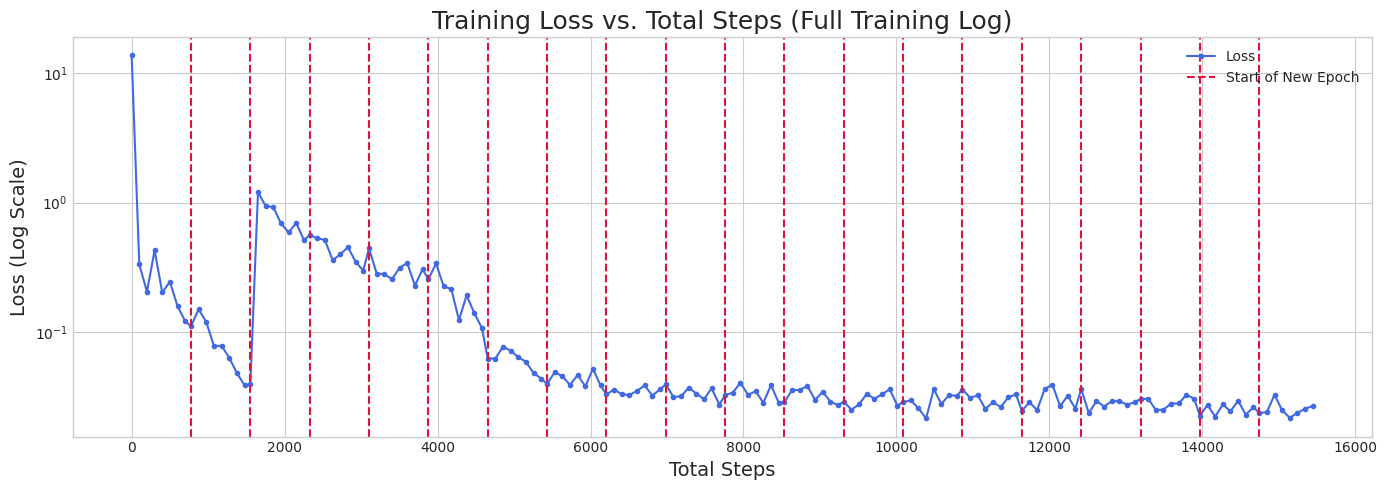

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_loss_with_epochs(df, extra_info=""):
	"""
	Plots the training loss versus total steps, with vertical lines indicating
	the start of a new epoch.

	Args:
		df (pandas.DataFrame): DataFrame with 'Step Total', 'Loss', and 'Epoch' columns.
	"""
	if df.empty or not all(col in df.columns for col in ['Step Total', 'Loss', 'Epoch']):
		print("DataFrame is empty or missing required columns.")
		return

	# Find the 'Step Total' values where a new epoch begins
	# We use .diff() to find where the 'Epoch' number changes from the previous row
	epoch_change_steps = df[df['Epoch'].diff() > 0]['Step Total'].tolist()

	# --- Plotting ---
	plt.style.use('seaborn-v0_8-whitegrid')
	plt.figure(figsize=(14, 5))

	# Plot the main Loss vs. Step Total curve
	plt.plot(df['Step Total'], df['Loss'], marker='.', linestyle='-', color='royalblue', label='Loss')

	# Add a vertical line for each epoch change
	for i, step in enumerate(epoch_change_steps):
		label = 'Start of New Epoch' if i == 0 else ""
		plt.axvline(x=step, color='crimson', linestyle='--', linewidth=1.5, label=label)

	# --- Formatting ---
	plt.title(f'Training Loss vs. Total Steps ({extra_info})', fontsize=18)
	plt.xlabel('Total Steps', fontsize=14)
	plt.ylabel('Loss (Log Scale)', fontsize=14)
	
	# Use a logarithmic scale for the y-axis to better visualize the data
	plt.yscale('log')
	
	plt.legend()
	plt.tight_layout()

	plt.show()




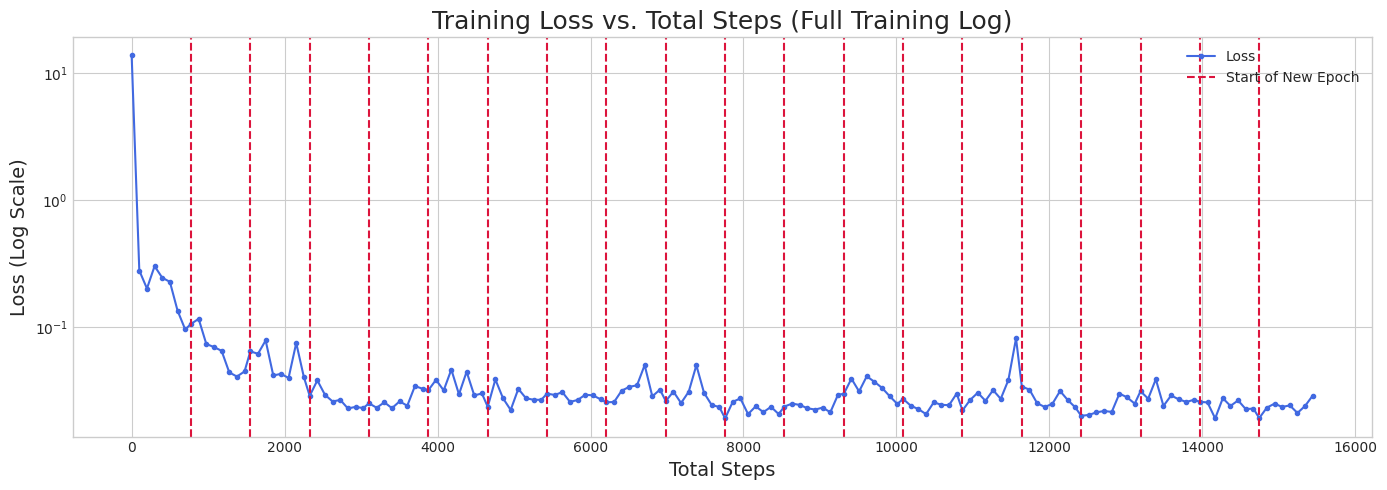

In [69]:
plot_loss_with_epochs(training_df.iloc[0:, :], extra_info="Full Training Log")

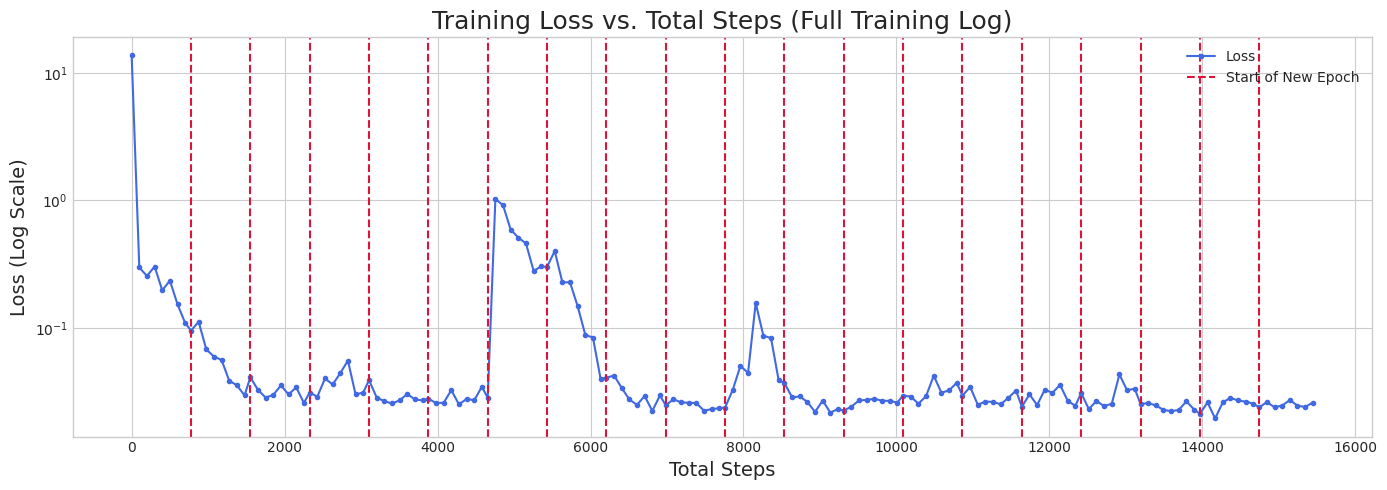

In [74]:
plot_loss_with_epochs(training_df.iloc[0:, :], extra_info="Full Training Log")

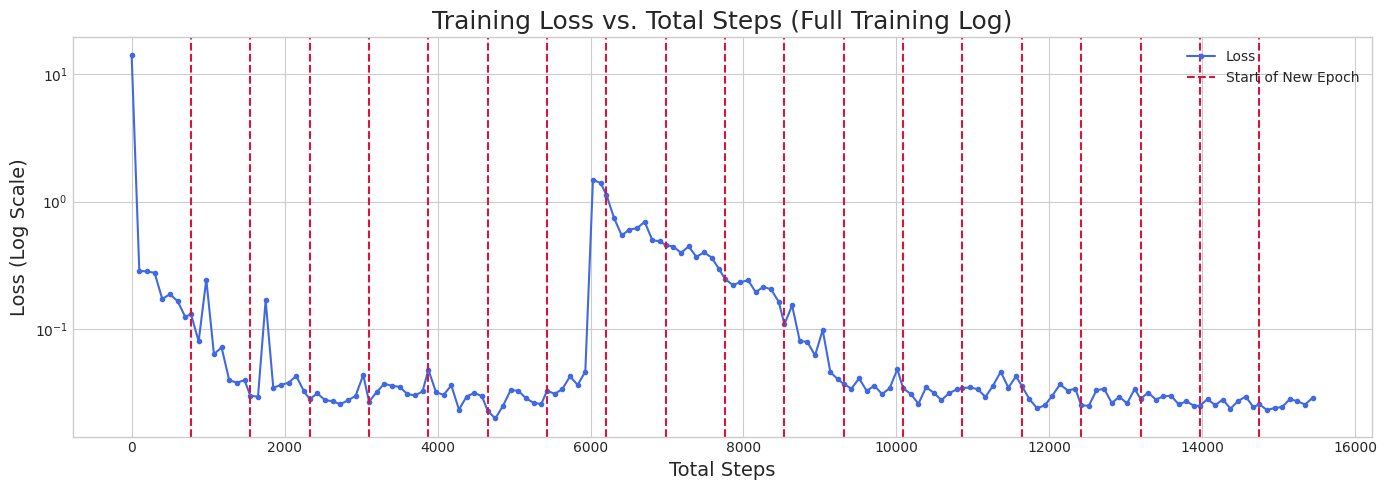

In [79]:
plot_loss_with_epochs(training_df.iloc[0:, :], extra_info="Full Training Log")

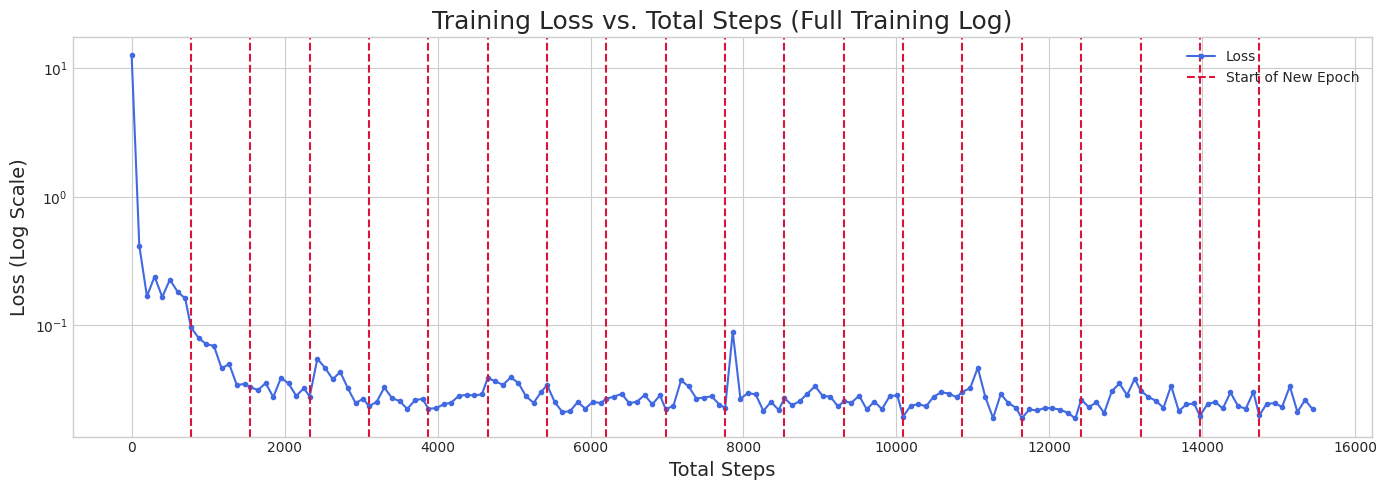

In [85]:
plot_loss_with_epochs(training_df.iloc[0:, :], extra_info="Full Training Log")